In [253]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [254]:
df = pd.read_csv("../Data/train.csv")
df.shape

(28362, 24)

In [255]:
drop_cols = ["Unnamed: 0","release_date", "age", "lyrics", "track_name", "artist_name", "genre", "topic"]
df.drop(columns=drop_cols, inplace=True, errors='ignore')
print("After drops, shape:", df.shape)


After drops, shape: (28362, 16)


Drop columns that are not needed for further analysis

We are removing age because we want to focus on thematic analysis

track_name, artist_name, genre, and topic dont have a score of 0-1 which won't help with our model training 

In [256]:
df.dropna(inplace=True)


In [257]:
df_variances = df.var()

In [258]:
threshold = 0.01
df_kept_cols = df_variances[df_variances >= threshold].index.tolist()
df_dropped_cols = df_variances[df_variances < threshold].index.tolist()

print("Keeping features with enough variation:", df_kept_cols)
print("Dropping features with low variation:", df_dropped_cols)


Keeping features with enough variation: ['len', 'violence', 'world/life', 'night/time', 'romantic', 'communication', 'obscene', 'music', 'sadness']
Dropping features with low variation: ['dating', 'shake the audience', 'family/gospel', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'feelings']


We are trying to prune out columns/features that have near constant variance. 

This is helpful because they will provide no help later in PCA and essentially ignored 

In [259]:
df_reduced = df[df_kept_cols].copy()
print("After low-variance pruning, shape:", df_reduced.shape)

After low-variance pruning, shape: (28362, 9)


In [260]:
means_before = df_reduced.mean()
std_before   = df_reduced.std()
print("Means before scaling:\n", means_before)
print("Standard deviations before scaling:\n", std_before)

Means before scaling:
 len              73.030534
violence          0.118371
world/life        0.120984
night/time        0.057356
romantic          0.048676
communication     0.076651
obscene           0.097185
music             0.060067
sadness           0.129402
dtype: float64
Standard deviations before scaling:
 len              41.831605
violence          0.178658
world/life        0.172216
night/time        0.111892
romantic          0.106071
communication     0.109497
obscene           0.181314
music             0.123346
sadness           0.181149
dtype: float64


Before feature scaling, we want to look at the mean and std to make sense of why we are scaling. 

As we can see, the different features(columns) have varying means and std so when we do PCA, it will result in an inaccurate model.

We need to do feature scaling, so all the mean and std are on the same footing making mean =0 and std=1. 

This is done so we don't have a mean outrageously large mean skewing the data since PCA is distance based model. 

In [261]:
scaler = StandardScaler()

In [262]:
scaler.fit(df_reduced)
print("\nScaler learned means (should match means_before):\n", scaler.mean_)
print("Scaler learned scale (std):\n", scaler.scale_)


Scaler learned means (should match means_before):
 [7.30305338e+01 1.18371198e-01 1.20983907e-01 5.73558488e-02
 4.86757749e-02 7.66505650e-02 9.71854861e-02 6.00667115e-02
 1.29401578e-01]
Scaler learned scale (std):
 [41.83086786  0.17865509  0.17221291  0.11188984  0.10606881  0.10949467
  0.18131128  0.1233438   0.18114608]


This is where we "study" the values and learn what will be the average values to subtract and how to scale all the features.


In [263]:
X_scaled = scaler.transform(df_reduced)
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (28362, 9)


This is where we actually do the calculations of subtracting and dividng to get all the features on the same footing

In [264]:
df_scaled = pd.DataFrame(scaler.transform(df_reduced), columns=df_reduced.columns)
means_after = df_scaled.mean()
std_after   = df_scaled.std()
print("\nMeans after scaling (≈0):\n", means_after)
print("Standard deviations after scaling (≈1):\n", std_after)


Means after scaling (≈0):
 len              8.016842e-18
violence        -1.603368e-17
world/life      -4.008421e-17
night/time      -5.010526e-17
romantic         4.409263e-17
communication   -2.405053e-17
obscene          3.206737e-17
music            2.004211e-17
sadness         -6.012632e-17
dtype: float64
Standard deviations after scaling (≈1):
 len              1.000018
violence         1.000018
world/life       1.000018
night/time       1.000018
romantic         1.000018
communication    1.000018
obscene          1.000018
music            1.000018
sadness          1.000018
dtype: float64


As we can see after feature scaling, we have all the means around 0 and all the std around 1. 

This allows us to use PCA because PCA treats each feature equally allowing a true thematic variance compared to a inaccurate scale of each features.



In [265]:
pca_full = PCA(random_state=42)
pca_full.fit(df_scaled)

PCA(random_state=42)

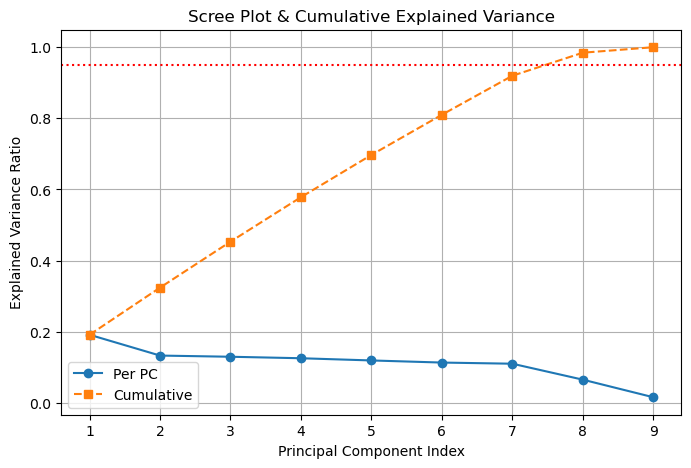

In [266]:
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, 'o-', label='Per PC')
plt.plot(range(1, len(explained)+1), cum_explained, 's--', label='Cumulative')
plt.axhline(y=0.95, color='r', linestyle=':')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot & Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

We are taking a look athe a pre-limited n_componenets to see where is the sweet spot.

Blue represents each individual prinicple componenets and orange is the cumulative where as we increase coponents we are increase % of total variance 

Our sweet spot is is around 8 because that is when variance starts to level off 

This tells us that to retain 95% of our total variance, we must have at least 8 componenets

In [267]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(df_scaled)
print("Reduced dimension:", X_pca.shape[1])

Reduced dimension: 8


We use 95% to keep almost all the signals but get rid of a few where the elbow point flattens meaning any more will be diminishing returns 

random_state is just used to seed the random number generator that will produce same results everytime randomness occurs

In [268]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_reduced.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("PCA Loadings (feature contributions):")
display(loadings)

PCA Loadings (feature contributions):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
len,0.596377,-0.101305,-0.007117,-0.093996,-0.020723,-0.020225,-0.038420,0.789215
violence,0.169487,0.800044,-0.310138,0.167479,-0.058008,0.096009,-0.059992,-0.012091
world/life,-0.181380,0.212345,0.782333,-0.332899,-0.011360,-0.129210,0.056844,0.129149
night/time,-0.070893,-0.116791,-0.053845,0.318938,0.822385,-0.335130,0.063852,0.091009
romantic,-0.263112,-0.199573,0.047070,0.132165,0.139599,0.765674,-0.407726,0.191734
communication,-0.080270,-0.066233,-0.236591,-0.341582,0.125038,0.362910,0.799212,0.060125
obscene,0.606340,-0.353878,0.057548,-0.114066,-0.009083,0.070738,-0.084841,-0.521190
music,-0.106584,-0.250121,0.096933,0.670046,-0.483286,-0.096262,0.328297,0.128573
sadness,-0.350719,-0.242757,-0.466819,-0.393006,-0.225808,-0.359354,-0.260113,0.153248


There are 8 prinicpal components which are basically bundles of features where there is a common direction or over arching theme 

All these 8 PC make up 95% of our total variance 

Each PC is like a bundle of features that vary together forming an theme/axis 

We can look into what each PC has in high variance(positive and negative values) and come up with a rough "theme" 

For example, PC 1 is high in len and obscene meaning it's a long & explicit songs will most go towards this axis and sadness with -0.3 will push away from this axis

With that info we can label PC 1 as Long & Explicit vs Emotional 

In [269]:
os.makedirs("Data", exist_ok=True)  # create directory if it doesn't exist
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
clean_df = pd.DataFrame(X_pca, columns=pc_cols)

In [270]:
clean_df.to_csv("../Data/clean_data_pca.csv", index=False)
print("Saved PCA-transformed data to ../Data/clean_data_pca.csv")

Saved PCA-transformed data to ../Data/clean_data_pca.csv
